In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

In [2]:
df = pd.read_csv('diabetes.csv')

print('--- Estructura del Dataset ---')
print(df.info())

print('\n--- Estadisticas Descriptivas ---')
print(df.describe())

--- Estructura del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pregnancies    768 non-null    int64  
 1   Glucose        768 non-null    int64  
 2   BloodPressure  768 non-null    int64  
 3   SkinThickness  768 non-null    int64  
 4   Insulin        768 non-null    int64  
 5   BMI            768 non-null    float64
 6   Pedigree       768 non-null    float64
 7   Age            768 non-null    int64  
 8   Outcome        768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

--- Estadisticas Descriptivas ---
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  

In [3]:
columnas_cero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in columnas_cero:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

In [4]:
X = df[['Glucose', 'BloodPressure', 'BMI', 'Age']]
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
print(f'Precision del diagnostico: {accuracy_score(y_test, y_pred)*100:.2f}%')

Precision del diagnostico: 74.03%


In [5]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[76 23]
 [17 38]]
              precision    recall  f1-score   support

           0       0.82      0.77      0.79        99
           1       0.62      0.69      0.66        55

    accuracy                           0.74       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.74      0.74       154



In [6]:
joblib.dump(knn, 'mejor_modelo_diabetes.pkl')
joblib.dump(scaler, 'escalador_diabetes.pkl')

['escalador_diabetes.pkl']

In [7]:
def interfaz_medica():
    modelo = joblib.load('mejor_modelo_diabetes.pkl')
    escalador = joblib.load('escalador_diabetes.pkl')

    print('--- SISTEMA DE PREDICCION DE DIABETES ---')
    glucosa = float(input('Ingrese nivel de Glucosa: '))
    presion = float(input('Ingrese Presion Arterial: '))
    bmi = float(input('Ingrese Indice de Masa Corporal (BMI): '))
    edad = int(input('Ingrese edad del paciente: '))

    datos_paciente = pd.DataFrame([[glucosa, presion, bmi, edad]],
                                  columns=['Glucose', 'BloodPressure', 'BMI', 'Age'])
    datos_scaled = escalador.transform(datos_paciente)

    prediccion = modelo.predict(datos_scaled)[0]
    probabilidad = modelo.predict_proba(datos_scaled)[0]

    print('\n--- RESULTADO DEL ANALISIS ---')
    print(f'Prediccion: {"DIABETES DETECTADA" if prediccion == 1 else "SIN DIABETES"}')
    print(f'Probabilidad de diabetes: {probabilidad[1]*100:.1f}%')
    print(f'Probabilidad de no diabetes: {probabilidad[0]*100:.1f}%')

    if prediccion == 1:
        print('\nRecomendacion: Se sugiere realizar examenes complementarios de hemoglobina glicosilada (HbA1c).')
    else:
        print('\nRecomendacion: Indicadores dentro de parametros normales. Mantener controles anuales.')

interfaz_medica()

--- SISTEMA DE PREDICCION DE DIABETES ---

--- RESULTADO DEL ANALISIS ---
Prediccion: DIABETES DETECTADA
Probabilidad de diabetes: 60.0%
Probabilidad de no diabetes: 40.0%

Recomendacion: Se sugiere realizar examenes complementarios de hemoglobina glicosilada (HbA1c).


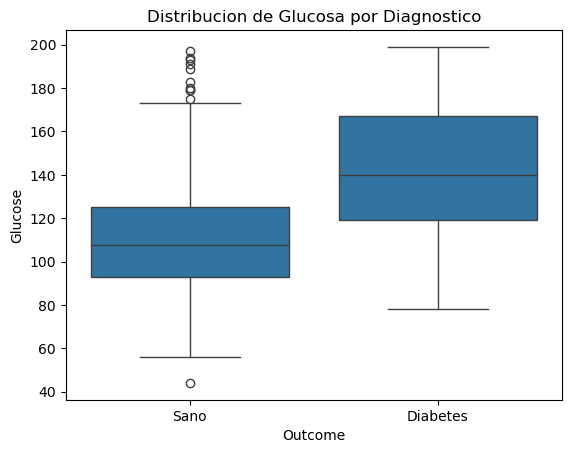

In [8]:
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.title('Distribucion de Glucosa por Diagnostico')
plt.xticks([0, 1], ['Sano', 'Diabetes'])
plt.show()

In [9]:
X_full = df.drop('Outcome', axis=1)
y_full = df['Outcome']

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_full, y_full, test_size=0.2, random_state=42)

scaler_full = StandardScaler()
X_train_f_scaled = scaler_full.fit_transform(X_train_f)
X_test_f_scaled = scaler_full.transform(X_test_f)

valores_k = [3, 5, 7, 9, 11, 13, 15]
resultados = {}

for k in valores_k:
    modelo_k = KNeighborsClassifier(n_neighbors=k)
    modelo_k.fit(X_train_f_scaled, y_train_f)
    pred_k = modelo_k.predict(X_test_f_scaled)
    acc = accuracy_score(y_test_f, pred_k)
    resultados[k] = acc
    print(f'K={k} -> Precision: {acc*100:.2f}%')

mejor_k = max(resultados, key=resultados.get)
print(f'\nMejor K encontrado: {mejor_k} con {resultados[mejor_k]*100:.2f}%')

K=3 -> Precision: 72.08%
K=5 -> Precision: 72.08%
K=7 -> Precision: 70.78%
K=9 -> Precision: 74.03%
K=11 -> Precision: 76.62%
K=13 -> Precision: 76.62%
K=15 -> Precision: 75.32%

Mejor K encontrado: 11 con 76.62%


In [10]:
knn_mejorado = KNeighborsClassifier(n_neighbors=mejor_k)
knn_mejorado.fit(X_train_f_scaled, y_train_f)
y_pred_mejorado = knn_mejorado.predict(X_test_f_scaled)

print(f'Precision mejorada: {accuracy_score(y_test_f, y_pred_mejorado)*100:.2f}%')
print()
print(confusion_matrix(y_test_f, y_pred_mejorado))
print()
print(classification_report(y_test_f, y_pred_mejorado))

Precision mejorada: 76.62%

[[83 16]
 [20 35]]

              precision    recall  f1-score   support

           0       0.81      0.84      0.82        99
           1       0.69      0.64      0.66        55

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.76      0.77      0.76       154



In [11]:
joblib.dump(knn_mejorado, 'mejor_modelo_diabetes.pkl')
joblib.dump(scaler_full, 'escalador_diabetes.pkl')
print('Modelo mejorado guardado.')

Modelo mejorado guardado.


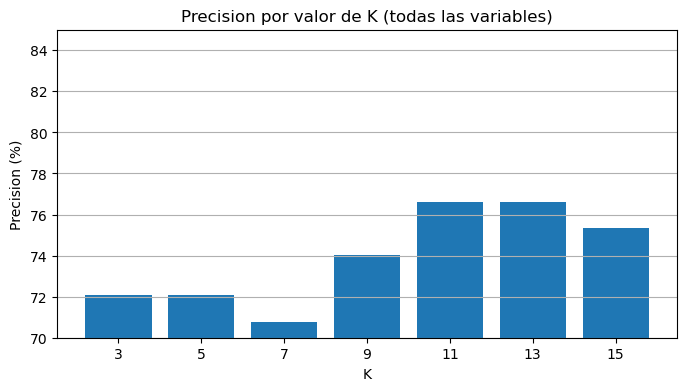

In [12]:
plt.figure(figsize=(8, 4))
plt.bar([str(k) for k in resultados.keys()], [v*100 for v in resultados.values()])
plt.xlabel('K')
plt.ylabel('Precision (%)')
plt.title('Precision por valor de K (todas las variables)')
plt.ylim(70, 85)
plt.grid(axis='y')
plt.show()